# Week5

In [76]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 15.0 MB/s eta 0:00:00m eta 0:00:010:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [92]:
import re
import requests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import datasets, models, transforms
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity

from collections import Counter
import spacy
import random

In [2]:
print(torch.cuda.is_available())

True


In [3]:
!nvidia-smi

Wed Mar 12 08:43:26 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.77                 Driver Version: 565.77         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   42C    P8              1W /   55W |      18MiB /  12282MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Introduction to Neural Networks

### Question: What are the building blocks of a NN?

- **Neurons (Nodes):** The basic processing units that receive input, apply an activation function, and produce output.  

- **Layers:**
  - **Input Layer:** Receives the initial data.  
  - **Hidden Layers:** Intermediate layers that process inputs.  
  - **Output Layer:** Produces the final result.  

- **Weights and Biases:** Parameters that adjust the strength of connections and influence neuron activation.  

- **Activation Functions:** Introduce non-linearity, enabling the network to model complex patterns.  

- **Connections (Edges):** Links between neurons that facilitate signal transmission.  

- **Learning Algorithm:** Methods like backpropagation that adjust weights based on errors to improve performance.  


### Question: How do Neurons work in Neural Networks? 

A **neuron**, also known as a **node** or **unit**, is the fundamental building block of a neural network. It processes inputs, applies a transformation, and produces an output that is passed to the next layer.

#### 1. Input Processing
Each neuron receives multiple inputs, represented as a vector:

$X = [x_1, x_2, ..., x_n]$

Each input is associated with a weight:

$W = [w_1, w_2, ..., w_n]$

The neuron also has a bias term, $b$, which allows for more flexibility in learning.

#### 2. Weighted Sum Calculation
The neuron computes the weighted sum of its inputs:

$z = \sum_{i=1}^{n} w_i x_i + b$

This linear combination represents the total input to the neuron before activation.

#### 3. Activation Function
To introduce non-linearity, the neuron applies an **activation function** to the weighted sum:

$a = f(z)$

Common activation functions include:

- **Sigmoid:**

  $f(z) = \frac{1}{1 + e^{-z}}$

  - Outputs values between 0 and 1.
  - Useful for probability-based outputs.

- **ReLU (Rectified Linear Unit):**

  $f(z) = \max(0, z)$

  - Introduces sparsity by setting negative values to 0.
  - Helps mitigate vanishing gradient problems.

- **Tanh (Hyperbolic Tangent):**

  $f(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$

  - Outputs values between -1 and 1.
  - Often preferred over sigmoid in hidden layers.

#### 4. Output Transmission
The activated value, $a$, is then passed to neurons in the next layer, contributing to the overall computation of the neural network.

Mathematically, the entire process of a neuron can be written as:

$a = f\left( \sum_{i=1}^{n} w_i x_i + b \right)$

Each neuron learns by adjusting its weights and bias using optimization techniques such as **gradient descent** and **backpropagation**, minimizing error and improving accuracy over time.

Neurons are the core units enabling deep learning models to extract patterns, recognize relationships, and make predictions.
```



### Basic Example: The World's Expensive Mostly Linear Regression (WEMLR)

Below we will:
- **Generate synthetic data** with a linear relationship.
- **Define Mean Squared Error (MSE)** as our loss function.
- **Initialize** random weights.
- **Perform gradient descent** updates.
- **Visualize** the training process.

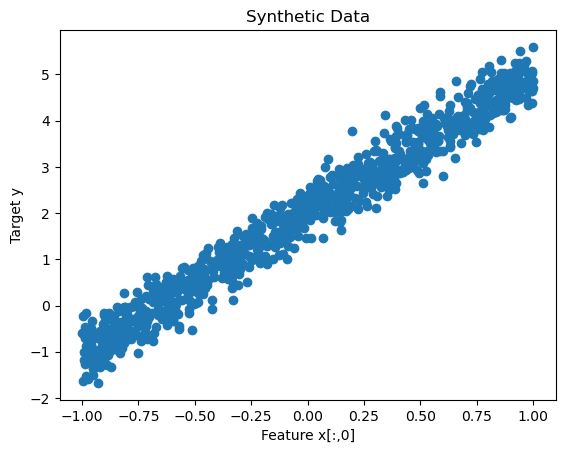

In [23]:
n = 1000  # Number of data points
x = torch.ones(n, 2)  # Feature matrix with two features
x[:, 0].uniform_(-1., 1)  # Randomize first feature between -1 and 1
a_true = torch.tensor([3., 2.])  # True weights
y = x @ a_true + torch.randn(n) / 3  # Linear relationship with noise

# Visualizing the data
plt.scatter(x[:, 0], y)
plt.title("Synthetic Data")
plt.xlabel("Feature x[:,0]")
plt.ylabel("Target y")
plt.show()


In [24]:
class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.hidden1 = nn.Linear(2, 10)  # First hidden layer (2 → 10 neurons)
        self.hidden2 = nn.Linear(10, 10)  # Second hidden layer (10 → 10 neurons)
        self.output = nn.Linear(10, 1)  # Output layer (10 → 1 neuron)
        self.activation = nn.ReLU()  # ReLU activation

    def forward(self, x):
        x = self.activation(self.hidden1(x))  # First hidden layer
        x = self.activation(self.hidden2(x))  # Second hidden layer
        x = self.output(x)  # Output layer (linear activation)
        return x

# Initialize model
model = NN()
print(model)  # Print model architecture

NN(
  (hidden1): Linear(in_features=2, out_features=10, bias=True)
  (hidden2): Linear(in_features=10, out_features=10, bias=True)
  (output): Linear(in_features=10, out_features=1, bias=True)
  (activation): ReLU()
)


Epoch 0, Loss: 7.5776
Epoch 10, Loss: 0.4442
Epoch 20, Loss: 0.7672
Epoch 30, Loss: 1.1948
Epoch 40, Loss: 1.1235
Epoch 50, Loss: 0.9672
Epoch 60, Loss: 0.8794
Epoch 70, Loss: 0.7678
Epoch 80, Loss: 0.6705
Epoch 90, Loss: 0.5982
Epoch 100, Loss: 0.5327
Epoch 110, Loss: 0.4831
Epoch 120, Loss: 0.4374
Epoch 130, Loss: 0.3950
Epoch 140, Loss: 0.3603
Epoch 150, Loss: 0.3278
Epoch 160, Loss: 0.2993
Epoch 170, Loss: 0.2781
Epoch 180, Loss: 0.2560
Epoch 190, Loss: 0.2394


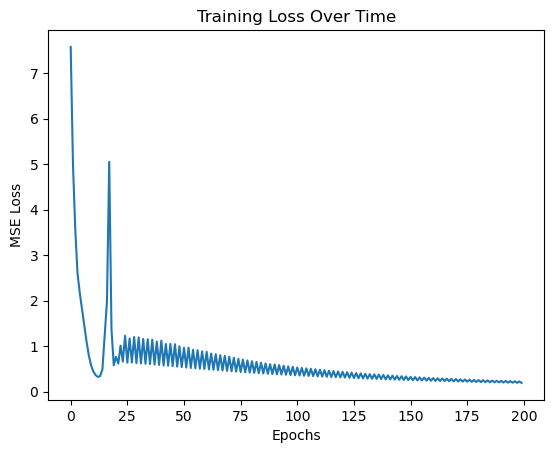

In [25]:
## Define Loss and Optimizer

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)  # Learning rate = 0.1


# Train Network with Backprop

epochs = 200
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()  # Reset gradients
    y_hat = model(x)  # Forward pass
    loss = criterion(y_hat.squeeze(), y)  # Compute loss
    loss.backward()  # Backpropagation
    optimizer.step()  # Update weights
    
    if epoch % 10 == 0:  
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")  # Print loss every 10 epochs
    
    losses.append(loss.item())

# Plot loss curve
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training Loss Over Time")
plt.show()


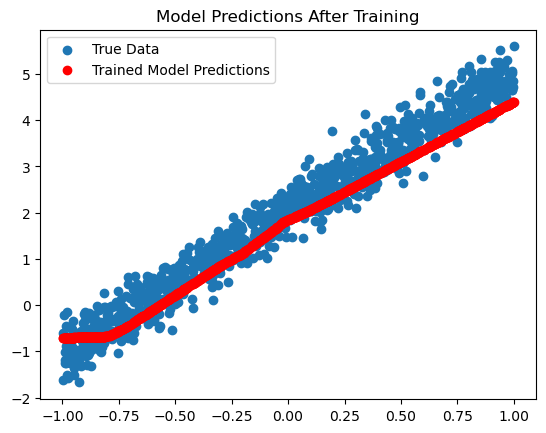

In [26]:
y_hat_final = model(x).detach()

plt.scatter(x[:, 0], y, label="True Data")
plt.scatter(x[:, 0], y_hat_final, label="Trained Model Predictions", color="red")
plt.legend()
plt.title("Model Predictions After Training")
plt.show()


### Question: What is an Activation Function, What Are Some Types, and Why Is It Important?


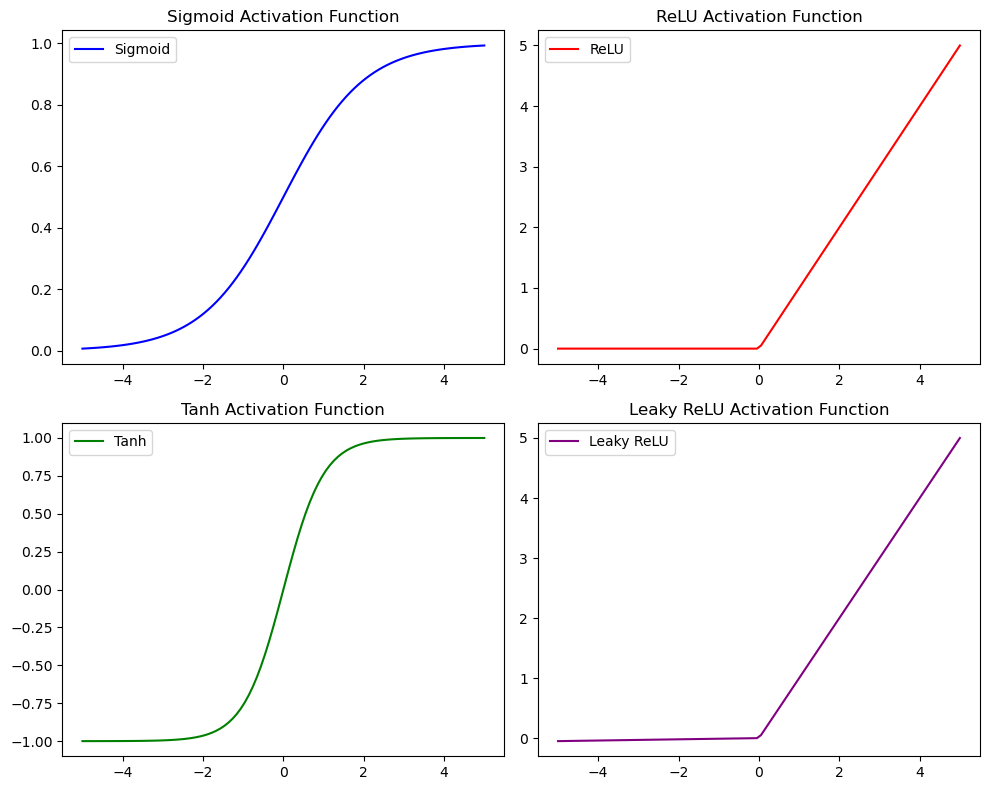

Sigmoid: Range (0,1), Pros: Good for probabilities, Cons: Vanishing gradient
ReLU: Range (0, ∞), Pros: Fast, avoids vanishing gradients, Cons: Dead neurons
Tanh: Range (-1,1), Pros: Zero-centered, Cons: Vanishing gradient
Leaky ReLU: Range (-∞,∞), Pros: Solves dead neurons, Cons: Still unbounded


In [28]:
# Define input range for visualization
x = torch.linspace(-5, 5, 100)

# Activation Function Definitions

def sigmoid(z):
    return 1 / (1 + torch.exp(-z))

def relu(z):
    return torch.max(torch.tensor(0.0), z)

def tanh(z):
    return (torch.exp(z) - torch.exp(-z)) / (torch.exp(z) + torch.exp(-z))

def leaky_relu(z, alpha=0.01):
    return torch.where(z > 0, z, alpha * z)

# Compute activation outputs
y_sigmoid = sigmoid(x)
y_relu = F.relu(x)
y_tanh = torch.tanh(x)
y_leaky_relu = F.leaky_relu(x, negative_slope=0.01)

# Plot Activation Functions
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].plot(x.numpy(), y_sigmoid.numpy(), label='Sigmoid', color='blue')
axs[0, 0].set_title("Sigmoid Activation Function")
axs[0, 0].legend()

axs[0, 1].plot(x.numpy(), y_relu.numpy(), label='ReLU', color='red')
axs[0, 1].set_title("ReLU Activation Function")
axs[0, 1].legend()

axs[1, 0].plot(x.numpy(), y_tanh.numpy(), label='Tanh', color='green')
axs[1, 0].set_title("Tanh Activation Function")
axs[1, 0].legend()

axs[1, 1].plot(x.numpy(), y_leaky_relu.numpy(), label='Leaky ReLU', color='purple')
axs[1, 1].set_title("Leaky ReLU Activation Function")
axs[1, 1].legend()

plt.tight_layout()
plt.show()

# Activation Function Summary Table
def print_activation_summary():
    activation_summary = {
        "Sigmoid": {"Range": "(0,1)", "Pros": "Good for probabilities", "Cons": "Vanishing gradient"},
        "ReLU": {"Range": "(0, ∞)", "Pros": "Fast, avoids vanishing gradients", "Cons": "Dead neurons"},
        "Tanh": {"Range": "(-1,1)", "Pros": "Zero-centered", "Cons": "Vanishing gradient"},
        "Leaky ReLU": {"Range": "(-∞,∞)", "Pros": "Solves dead neurons", "Cons": "Still unbounded"}
    }
    for name, details in activation_summary.items():
        print(f"{name}: Range {details['Range']}, Pros: {details['Pros']}, Cons: {details['Cons']}")

print_activation_summary()

### Question: What is MLP?

An MLP is a type of feedforward artificial neural network that consists of:

1) An input layer (receives the input features)
2) One or more hidden layers (processes and transforms the data)
3) An output layer (produces the final prediction)

### Basic Activation Problem


Training models for 25 epochs...
ReLU Training Complete (Epochs: 25): Final Loss: 2.864559
Sigmoid Training Complete (Epochs: 25): Final Loss: 5.379210
Tanh Training Complete (Epochs: 25): Final Loss: 2.767518
LeakyReLU Training Complete (Epochs: 25): Final Loss: 3.496307

The winner for 25 epochs is: Tanh with loss 2.767518


Training models for 100 epochs...
ReLU Training Complete (Epochs: 100): Final Loss: 1.818356
Sigmoid Training Complete (Epochs: 100): Final Loss: 1.613204
Tanh Training Complete (Epochs: 100): Final Loss: 1.023653
LeakyReLU Training Complete (Epochs: 100): Final Loss: 1.381239

The winner for 100 epochs is: Tanh with loss 1.023653


Training models for 500 epochs...
ReLU Training Complete (Epochs: 500): Final Loss: 0.039862
Sigmoid Training Complete (Epochs: 500): Final Loss: 0.895196
Tanh Training Complete (Epochs: 500): Final Loss: 0.045833
LeakyReLU Training Complete (Epochs: 500): Final Loss: 0.036001

The winner for 500 epochs is: LeakyReLU with loss 0.0360

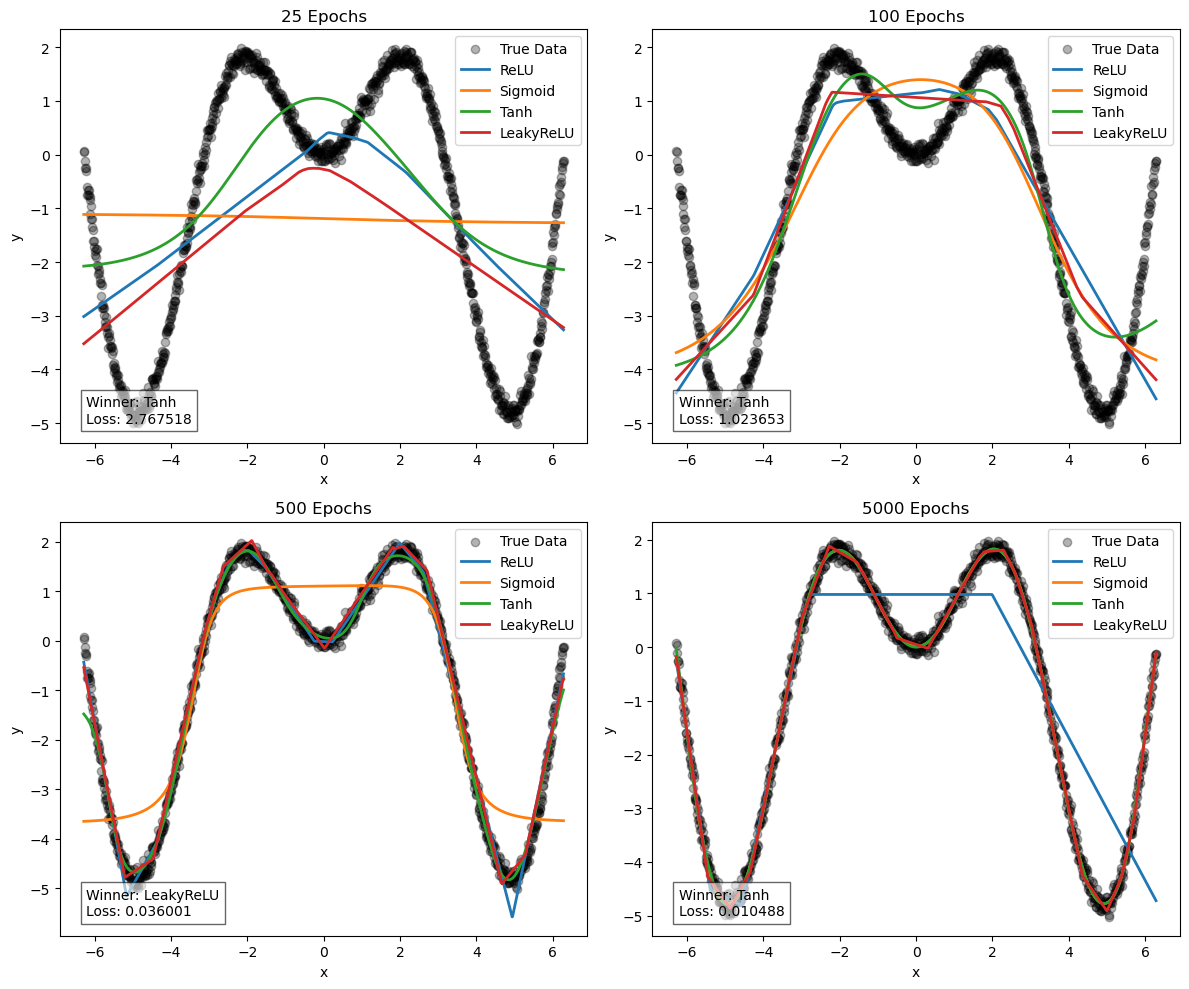

In [36]:
# Generate noisy sine wave data
n = 1000  # Number of data points
x = torch.linspace(-2 * np.pi, 2 * np.pi, n).reshape(-1, 1)
y = x * torch.sin(x) + 0.1 * torch.randn(n, 1)  # Adding noise

# Function to create different models with varying activation functions
def create_model(activation_fn):
    class NN(nn.Module):
        def __init__(self):
            super(NN, self).__init__()
            self.hidden1 = nn.Linear(1, 10)
            self.hidden2 = nn.Linear(10, 10)
            self.output = nn.Linear(10, 1)
            self.activation = activation_fn
        
        def forward(self, x):
            x = self.activation(self.hidden1(x))
            x = self.activation(self.hidden2(x))
            x = self.output(x)
            return x
    return NN()

# Define different activation functions
activations = {
    'ReLU': nn.ReLU(),
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh(),
    'LeakyReLU': nn.LeakyReLU()
}

# Epoch sizes to compare
epoch_sizes = [25, 100, 500, 5000]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# Train models and compare results
for idx, epochs in enumerate(epoch_sizes):
    print(f'\nTraining models for {epochs} epochs...')
    trained_models = {}
    best_loss = float('inf')
    best_model = None
    best_activation = None
    
    for name, activation in activations.items():
        model = create_model(activation)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.01)
        
        # Training loop
        for epoch in range(epochs):
            optimizer.zero_grad()
            y_pred = model(x)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
        
        trained_models[name] = model
        print(f'{name} Training Complete (Epochs: {epochs}): Final Loss: {loss.item():.6f}')
        
        # Track the best model
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_model = model
            best_activation = name
    
    print(f'\nThe winner for {epochs} epochs is: {best_activation} with loss {best_loss:.6f}\n')
    
    # Plot predictions for each activation function in a 2x2 grid
    ax = axes[idx]
    ax.scatter(x.numpy(), y.numpy(), label='True Data', color='black', alpha=0.3)
    for name, model in trained_models.items():
        y_pred = model(x).detach().numpy()
        ax.plot(x.numpy(), y_pred, label=name, linewidth=2)  # Thickened model lines
    
    ax.set_title(f'{epochs} Epochs')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    
    # Add winner text inside the plot
    ax.text(0.05, 0.05, f'Winner: {best_activation}\nLoss: {best_loss:.6f}', transform=ax.transAxes,
            fontsize=10, bbox=dict(facecolor='white', alpha=0.6))

# Adjust layout and show the full figure
plt.tight_layout()
plt.show()


### Question: What are the key challenges in training deep neural networks, and how are they addressed?

- Overfitting and regularization techniques like dropout and weight decay.
- Vanishing and Exploding Gradients and how optimizers like Adam and activation functions like ReLU help.
- Computational Costs and parallelization methods.
- Data Efficiency and transfer learning.

### Architecture Exploration

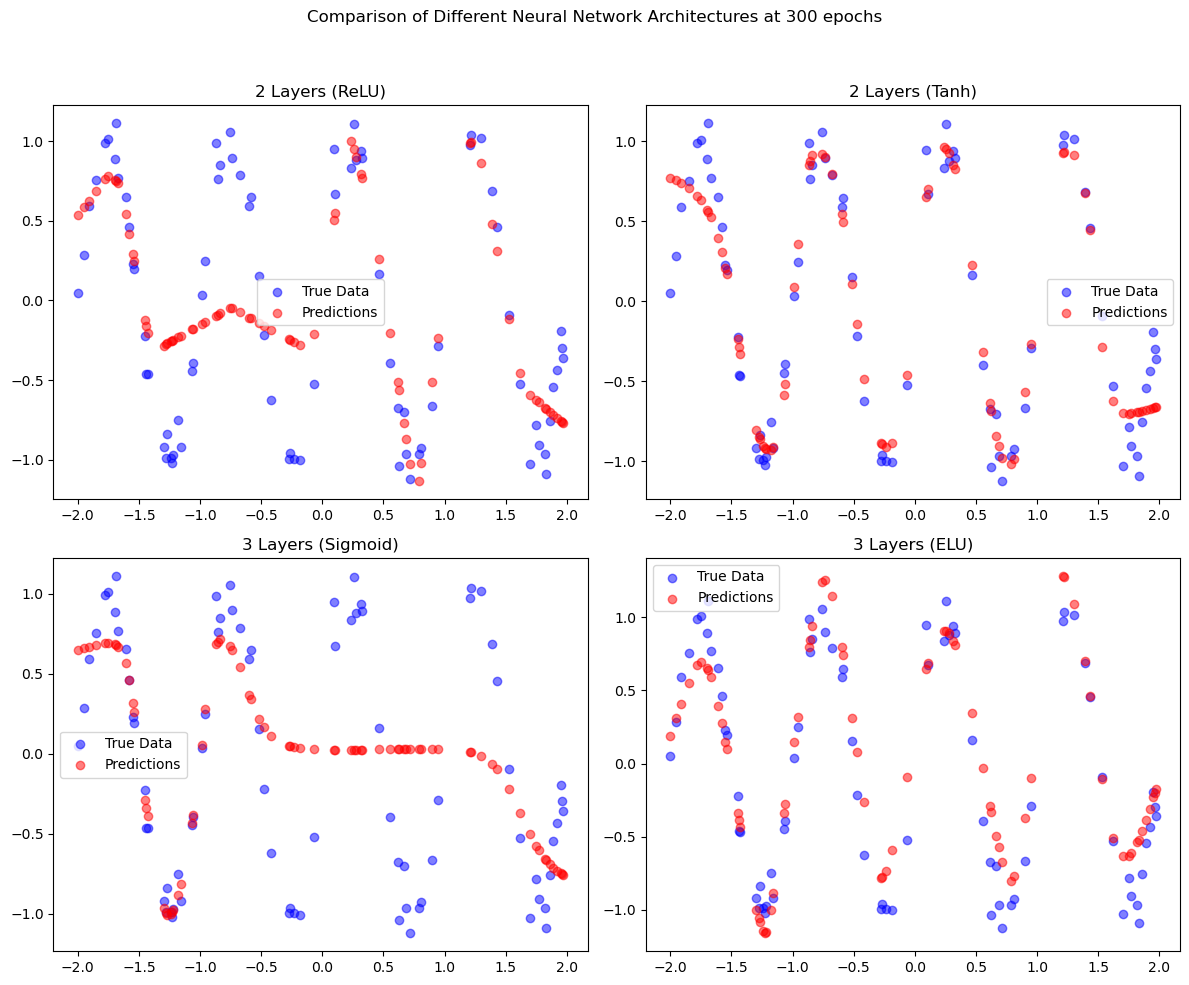

In [45]:
# Generate synthetic dataset (Non-linear)
np.random.seed(42)
X = np.linspace(-2, 2, 400).reshape(-1, 1)
y = np.sin(2 * np.pi * X).flatten() + np.random.normal(0, 0.1, X.shape[0])

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

epoch_selection = 300

# Define different model architectures and activation functions
architectures = [
    {"layers": [10, 10], "activation": nn.ReLU(), "name": "2 Layers (ReLU)", "epochs": epoch_selection},
    {"layers": [20, 20], "activation": nn.Tanh(), "name": "2 Layers (Tanh)", "epochs": epoch_selection},
    {"layers": [50, 50, 50], "activation": nn.Sigmoid(), "name": "3 Layers (Sigmoid)", "epochs": epoch_selection},
    {"layers": [100, 100, 100], "activation": nn.ELU(), "name": "3 Layers (ELU)", "epochs": epoch_selection}
]

# Training function
def train_model(model, criterion, optimizer, X_train, y_train, epochs):
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
    return model

# Train models and store results
results = {}

for arch in architectures:
    class NeuralNetwork(nn.Module):
        def __init__(self):
            super(NeuralNetwork, self).__init__()
            layers = []
            input_size = 1
            for hidden_units in arch["layers"]:
                layers.append(nn.Linear(input_size, hidden_units))
                layers.append(arch["activation"])
                input_size = hidden_units
            layers.append(nn.Linear(input_size, 1))
            self.model = nn.Sequential(*layers)

        def forward(self, x):
            return self.model(x)

    model = NeuralNetwork()
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    model = train_model(model, criterion, optimizer, X_train_tensor, y_train_tensor, arch["epochs"])
    
    # Predictions
    with torch.no_grad():
        y_pred = model(X_test_tensor).numpy()
    
    results[arch["name"]] = (X_test, y_test, y_pred)

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f"Comparison of Different Neural Network Architectures at {epoch_selection} epochs")

for ax, (name, (X_t, y_t, y_p)) in zip(axes.flat, results.items()):
    ax.scatter(X_t, y_t, label="True Data", color="blue", alpha=0.5)
    ax.scatter(X_t, y_p, label="Predictions", color="red", alpha=0.5)
    ax.set_title(name)
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Feed Forward Neural Network Language Model

### Question: What is the role of word embeddings and One-hot encoding in neural language models, and how do they improve representation?

Word embeddings are a crucial component in neural language models, enabling words to be represented as dense, lower-dimensional vectors that capture semantic and syntactic relationships.

One-Hot Encoding vs. Word Embeddings

Traditional word representation in neural networks relied on one-hot encoding.
However, this method has limitations:
- High dimensionality (equal to vocabulary size)
- No inherent similarity between words
- Sparsity leading to inefficient computations
- 
Word embeddings address these issues by learning meaningful representations.

### Question: What are some of the advantages of Word Embeddings over One-Hot encoding?

- **Captures Semantic Meaning**: Similar words have similar vectors (e.g., "king" and "queen" are close together).
- **Lower Dimensionality**: Instead of sparse vectors with size equal to vocabulary, embeddings typically have 50-500 dimensions.
- **Context Awareness**: Words with similar meanings are positioned near each other in the vector space.
- **Efficient Computation**: Reduces the computational burden compared to one-hot encoding.

### Python Example

In [69]:
# Download and clean the text from Project Gutenberg
url = "https://www.gutenberg.org/cache/epub/1523/pg1523.txt"
response = requests.get(url)
text = response.text

# Extract only the play content (remove Gutenberg headers/footers)
start_idx = text.find("Dramatis Personæ")
end_idx = text.find("*** END OF THE PROJECT GUTENBERG EBOOK AS YOU LIKE IT ***")
play_text = text[start_idx:end_idx]


In [72]:
print(play_text[0:300])

Dramatis Personæ

ORLANDO, youngest son of Sir Rowland de Boys
OLIVER, eldest son of Sir Rowland de Boys
JAQUES DE BOYS, second son of Sir Rowland de Boys
ADAM, Servant to Oliver
DENNIS, Servant to Oliver

ROSALIND, Daughter of Duke Senior
CELIA, Daughter of Duke Frederick
TOUCHSTONE, a Cl


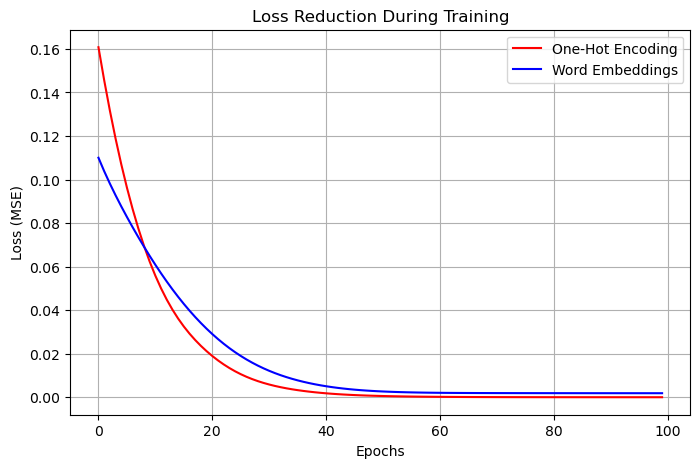

In [83]:
### Comparing One-Hot Encoding vs. Word Embeddings for Modeling Shakespeare's As You Like It

import requests
import spacy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from collections import Counter
import re

# Download and clean the text from Project Gutenberg
url = "https://www.gutenberg.org/cache/epub/1523/pg1523.txt"
response = requests.get(url)
text = response.text

# Extract only the play content (remove Gutenberg headers/footers)
start_idx = text.find("Dramatis Person\u00e6")
end_idx = text.find("*** END OF THE PROJECT GUTENBERG EBOOK AS YOU LIKE IT ***")
play_text = text[start_idx:end_idx]

# Basic text cleanup
play_text = re.sub(r'[^a-zA-Z\s]', '', play_text)  # Remove punctuation
words = play_text.lower().split()

# Limit vocabulary size
vocab_size = 20_000  # Limit vocabulary for one-hot encoding
word_counts = Counter(words)
vocab = [word for word, _ in word_counts.most_common(vocab_size - 1)]  # Reserve space for UNK token
word_to_index = {word: i for i, word in enumerate(vocab)}
word_to_index["UNK"] = vocab_size - 1

# Convert words to indices (handling unknown words)
indexed_text = [word_to_index.get(word, word_to_index["UNK"]) for word in words]

# One-Hot Encoding
one_hot_encoder = OneHotEncoder(sparse_output=False, categories=[list(range(vocab_size))])
one_hot_vectors = one_hot_encoder.fit_transform(np.array(indexed_text).reshape(-1, 1))

# Load SpaCy model for word embeddings
nlp = spacy.load("en_core_web_md")

def get_word_vector(word):
    return nlp(word).vector if word in nlp.vocab else np.zeros((300,))

# Generate word vectors for the same words
word_vectors = np.array([get_word_vector(word) for word in vocab])

# Define a simple 3x3 neural network
class SimpleNN(nn.Module):
    def __init__(self, input_size):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 3)
        self.fc2 = nn.Linear(3, 3)
        self.fc3 = nn.Linear(3, input_size)
        self.activation = nn.ReLU()
    
    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)
        return x

# Training function
def train_model(model, X_train, Y_train, epochs=100):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, Y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

# Train with One-Hot Encoded Inputs
input_size = vocab_size
model_one_hot = SimpleNN(input_size)
X_train_one_hot = torch.tensor(one_hot_vectors[:1000], dtype=torch.float32)  # Use first 1000 words for training
Y_train_one_hot = X_train_one_hot.clone()
losses_one_hot = train_model(model_one_hot, X_train_one_hot, Y_train_one_hot)

# Train with Word Embedding Inputs
input_size = 300  # SpaCy embeddings are 300-dimensional
model_word_vec = SimpleNN(input_size)
X_train_vec = torch.tensor(word_vectors, dtype=torch.float32)
Y_train_vec = X_train_vec.clone()
losses_word_vec = train_model(model_word_vec, X_train_vec, Y_train_vec)

# Plot accuracy (loss reduction over epochs)
plt.figure(figsize=(8, 5))
plt.plot(losses_one_hot, label="One-Hot Encoding", color='red')
plt.plot(losses_word_vec, label="Word Embeddings", color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Loss Reduction During Training")
plt.legend()
plt.grid()
plt.show()

# Perform a simple prediction comparison
def predict(model, X_sample):
    with torch.no_grad():
        return model(X_sample).numpy()

sample_index = np.random.randint(0, 1000)

one_hot_prediction = predict(model_one_hot, X_train_one_hot[sample_index].unsqueeze(0))
word_vec_prediction = predict(model_word_vec, X_train_vec[sample_index].unsqueeze(0))

### Question: Why is the Softmax Function Used in the Output Layer, and How Does It Ensure a Probability Distribution?


#### 1. Purpose of the Softmax Function
The **Softmax function** is commonly used in the output layer of neural networks for **classification tasks**, including **language modeling**. It converts raw scores (logits) from the network into a probability distribution over possible output classes (e.g., words in a vocabulary).

#### 2. Definition of Softmax
Mathematically, given a vector of logits $z = [z_1, z_2, ..., z_k]$, the softmax function computes the probability of each class $i$ as:

$$
P(y = i | z) = \frac{e^{z_i}}{\sum_{j=1}^{k} e^{z_j}}
$$

where:
- $e^{z_i}$ exponentiates the raw score to ensure non-negative values.
- The denominator normalizes all exponentiated values to sum to 1, forming a valid probability distribution.

#### 3. Ensuring a Probability Distribution
The Softmax function guarantees two key properties:
- **Non-negativity**: Since exponentiation ($e^{z_i}$) always produces positive values, all outputs are $\geq 0$.
- **Normalization**: The denominator ensures that the sum of all outputs equals 1:

  $$
  \sum_{i=1}^{k} P(y = i | z) = \sum_{i=1}^{k} \frac{e^{z_i}}{\sum_{j=1}^{k} e^{z_j}} = 1
  $$

Thus, the softmax output can be interpreted as a probability distribution over classes.

#### 4. Example Calculation
Assume a neural network outputs the following raw logits for three possible words:

$$ z = [2.0, 1.0, 0.1] $$

Applying Softmax:

1. Compute exponentials:
   $$ e^2.0 \approx 7.39, \quad e^1.0 \approx 2.72, \quad e^{0.1} \approx 1.10 $$

2. Compute the sum:
   $$ 7.39 + 2.72 + 1.10 = 11.21 $$

3. Normalize each value:
   $$ P_1 = \frac{7.39}{11.21} \approx 0.66, \quad P_2 = \frac{2.72}{11.21} \approx 0.24, \quad P_3 = \frac{1.10}{11.21} \approx 0.10 $$

These values represent a probability distribution over the three possible words.

#### 5. Importance in Language Models
In neural language models, the Softmax function allows the model to:
- **Generate probabilities** for each word in the vocabulary as the next word.
- **Make predictions** by selecting the word with the highest probability.
- **Train effectively** using a cross-entropy loss function, which compares predicted probabilities with actual labels.

#### 6. Summary
- The **Softmax function** converts raw network outputs into a probability distribution.
- It ensures all outputs are **non-negative** and **sum to 1**.
- This allows the model to **interpret predictions probabilistically**, making it suitable for classification and sequence modeling tasks like machine translation.
```



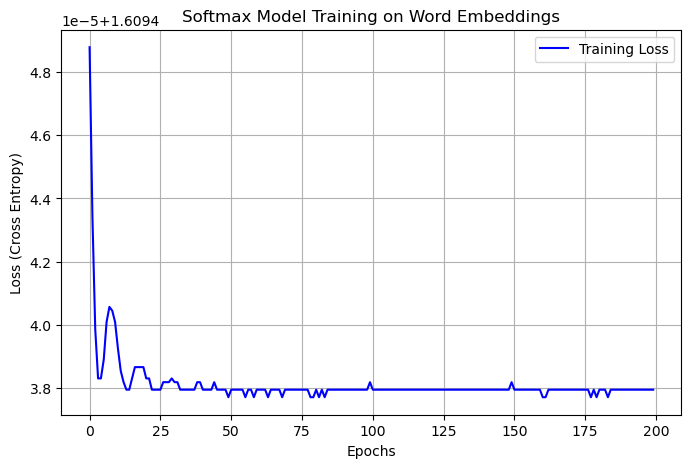

Predictions for word: king
[[0.19999985 0.20000002 0.20000027 0.19999991 0.19999994]]


In [88]:
# Load SpaCy model for word embeddings
nlp = spacy.load("en_core_web_md")

def get_word_vector(word):
    return nlp(word).vector if word in nlp.vocab else np.zeros((300,))

# Example words to compare softmax probabilities
words = ["king", "queen", "man", "woman", "apple"]
word_vectors = np.array([get_word_vector(word) for word in words])

# Convert to torch tensors
word_tensor = torch.tensor(word_vectors, dtype=torch.float32)

# Define a simple Softmax-based model
class SoftmaxModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(SoftmaxModel, self).__init__()
        self.fc = nn.Linear(input_size, output_size)
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, x):
        x = self.fc(x)
        return self.softmax(x)

# Define model, loss, and optimizer
input_size = 300  # SpaCy word vector size
output_size = len(words)  # Number of classes
model = SoftmaxModel(input_size, output_size)

# Generate random labels for training
labels = torch.tensor([i for i in range(len(words))], dtype=torch.long)
labels = torch.nn.functional.one_hot(labels, num_classes=output_size).float()

# Training function
def train_model(model, X_train, Y_train, epochs=200):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, Y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

# Train model
losses = train_model(model, word_tensor, labels)

# Plot loss reduction
plt.figure(figsize=(8, 5))
plt.plot(losses, label="Training Loss", color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss (Cross Entropy)")
plt.title("Softmax Model Training on Word Embeddings")
plt.legend()
plt.grid()
plt.show()

# Perform predictions
def predict(model, X_sample):
    with torch.no_grad():
        return model(X_sample).numpy()

sample_index = np.random.randint(0, len(words))
predictions = predict(model, word_tensor[sample_index].unsqueeze(0))

print(f"Predictions for word: {words[sample_index]}")
print(predictions)


### How Did the Transition from Statistical Language Models to Neural Language Models Impact Machine Translation?

The shift from **Statistical Machine Translation (SMT)** to **Neural Machine Translation (NMT)** has dramatically improved translation quality. SMT relied on probabilistic models, whereas NMT utilizes deep learning techniques to capture linguistic patterns more effectively.

#### 2. Limitations of Statistical Language Models in SMT
Statistical Machine Translation was based on:
- **Phrase-Based Translation**: Translations were generated by breaking sentences into phrases and matching them statistically.
- **N-gram Language Models**: Modeled the probability of word sequences but struggled with long-range dependencies.
- **Feature Engineering**: Required manual tuning of multiple translation rules.

Challenges:
- **Lack of Context Understanding**: SMT treated sentences as independent units, leading to unnatural translations.
- **Data Sparsity**: Rare word combinations had low probabilities, reducing translation quality.
- **Error Propagation**: Separate translation and reordering models often compounded errors.

#### 3. Advantages of Neural Language Models in NMT
Neural Machine Translation introduced:
- **Sequence-to-Sequence Models**: Directly mapped input sentences to output sentences using deep neural networks.
- **Word Embeddings**: Represented words in a continuous vector space, capturing semantic relationships.
- **End-to-End Learning**: Eliminated the need for manually engineered features.

Key Benefits:
- **Better Context Handling**: Uses **Recurrent Neural Networks (RNNs)**, **Long Short-Term Memory (LSTMs)**, and **Transformers** to model long-range dependencies.
- **Improved Fluency**: Neural networks learn smooth transitions between words, producing more natural translations.
- **Generalization**: Embeddings help the model infer meanings even for unseen words, unlike SMT's rigid phrase-based approach.

#### 4. The Role of the Transformer Model
- **Self-Attention Mechanism**: Unlike RNNs, **Transformers** capture relationships between words regardless of their position in a sentence.
- **Parallel Processing**: Speeds up training and inference, making large-scale translation more feasible.
- **State-of-the-Art Performance**: Used in modern translation models like **Google Translate** and **OpenAI’s GPT models**.

#### 5. Performance Comparison: SMT vs. NMT
| Feature | Statistical Machine Translation (SMT) | Neural Machine Translation (NMT) |
|---------|--------------------------------|--------------------------------|
| **Context Handling** | Limited to local phrases | Captures long-range dependencies |
| **Fluency** | Rigid and formulaic | More natural and coherent |
| **Word Representation** | Uses word alignments | Uses word embeddings |
| **Error Handling** | Error-prone due to independent modules | End-to-end training reduces errors |
| **Scalability** | Struggles with large data | Easily scales with more data |

#### 6. Summary
The transition from SMT to NMT has led to:
- **More fluent and natural translations**
- **Better generalization to new languages and domains**
- **Reduced need for manual feature engineering**
- **Faster and more scalable models**

Neural networks, especially **Transformer-based models**, now define the state-of-the-art in machine translation.
```



## Reccurent Neural Network Language Model

### Question: Why do we need RNNs?

Limitation of Feedforward Neural Networks (FFNNs):

- FFNNs only use a fixed number of previous words (e.g., N−1N−1 words) to predict the next word.
- They cannot capture long-term dependencies, which is problematic in languages with complex sentence structures (e.g., German with long-distance verb dependencies).

Solution: Recurrent Neural Networks (RNNs)

- RNNs maintain a hidden state that persists across time steps.
- Each hidden state depends not only on the current input but also on the previous hidden state, allowing information to propagate over long distances.

### RNN Character by Character Example

In [108]:
all_characters = list(set(play_text))
n_characters = len(all_characters)

chunk_len = 400

def random_chunk():
    start_index = random.randint(0, len(play_text) - chunk_len)
    end_index = start_index + chunk_len + 1
    return play_text[start_index:end_index]

print(random_chunk())

hath made thee
a tame snake and say this to her that if she love me I charge her to
love thee if she will not I will never have her unless thou entreat
for her If you be a true lover hence and not a word for here comes
more company

Exit Silvius

Enter Oliver

OLIVER
Good morrow fair ones Pray you if you know
Where in the purlieus of this forest stands
A sheepcote fenced about with oli


In [116]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_layers=1):
        super(RNN, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers
        
        self.encoder = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, n_layers)
        self.decoder = nn.Linear(hidden_size, output_size)
        
    def forward(self, input, hidden):
        output = self.encoder(input.view(1, -1))
        output, hidden = self.gru(output.view(1, 1, -1), hidden)
        output = self.decoder(output.view(1, -1))
        
        return output, hidden
    
    def init_hidden(self):
        return Variable(torch.randn(self.n_layers, 1, self.hidden_size))

def char2tensor(string):
    tensor = torch.zeros(len(string)).long()
    for char in range(len(string)):
        if string[char] in all_characters:
            tensor[char] = all_characters.index(string[char])
        else:
            tensor[char] = 94 #predict space if character unknown
        
    return Variable(tensor)

# Let's see it in action.
print(char2tensor('Metis0123abczABC'))

tensor([39, 44, 37, 27,  7, 94, 94, 94, 94, 19, 31, 52, 14, 32,  3, 33])


In [ ]:
def random_training_set():
    chunk = random_chunk()
    inp = char2tensor(chunk[:-1])
    target = char2tensor(chunk[1:])
    return inp, target

def evaluate(model, prime_str='A', predict_len=100, temperature=0.8):
    
    hidden = model.init_hidden()
    prime_input = char2tensor(prime_str)
    predicted = prime_str
    
    # use priming string to build up hidden state
    
    for p in range(len(prime_str) - 1):
        _, hidden = model(prime_input[p], hidden)
    inp = prime_input[-1]
    
    for p in range(predict_len):
        output, hidden = model(inp, hidden)
        
        # Sample from the network as a multinomial distribution
        output_dist = output.data.view(-1).div(temperature).exp()
        top_i = torch.multinomial(output_dist, 1)[0]
        
        # Add predicted character to string and use as next input
        predicted_char = all_characters[top_i]
        predicted += predicted_char
        inp = char2tensor(predicted_char)
        
    return predicted

# helper function
import time, math

def time_since(since):
    s = time.time() - since
    m = math.floor(s/60)
    s -= m*60
    return '%dm %ds' % (m, s)

# The actual training part
def train(inp, target):
    hidden = model.init_hidden()
    model.zero_grad()
    loss = 0

    for char in range(chunk_len):
        output, hidden = model(inp[char], hidden)
        loss += criterion(output, target[char].unsqueeze(0))

    loss.backward()
    model_optimizer.step()

    return loss.data.item() / chunk_len

In [115]:
# parameters
n_epochs = 1000
print_every = 100
plot_every = 10
hidden_size = 256
n_layers = 2
learning_rate = 0.001

# model declaration
model = RNN(n_characters, hidden_size, n_characters, n_layers)
model_optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

start = time.time()
all_losses = []
loss_avg = 0

for epoch in range(1, n_epochs + 1):
    loss = train(*random_training_set())       
    loss_avg += loss

    if epoch % print_every == 0:
        print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch, epoch / n_epochs * 100, loss))
        print(evaluate(model, 'A ', 100), '\n')

    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0

 36s (100 10%) 2.0151]
A mak shere I made romor hut mand

AETur dill I the or he win or you wher bais whand wier wame the
 

 16s (200 20%) 1.7837]
A Oar do then bane frees what world
But hing the no do there and a pocmsary haon you thuro

ROSLIND 

 5s (300 30%) 1.9647]
A chear good see a tis gecon

ROSALIND
Cay sevent twening not dy peny

TOUCHSTONE
Of man and is  

 50s (400 40%) 1.6512]
A not sir Fartemen to the can of is mores

ROSALIND
You your be me canty the poor like for hath tha 

 38s (500 50%) 1.6967]
A a woman
Hone a dies liyg he mare I spricking and your have time the wisely

SCENE II And I were t 

 25s (600 60%) 1.4689]
A you am

OLIVER
And to when he marry martain her
her would mut your bear and more thank than
    

 10s (700 70%) 1.2249]
A Lorber me thou are again

OLIVER
Make to place mine you dust be meworress not with my frails what 

 0s (800 80%) 1.3744]
A content

CELIA
And the love we judges sure like my man

TOUCHSTONE
And therest not hell a live 

 40s (900 

### Word By Word LSTM

In [121]:
import torch
import torch.nn as nn
import torch.optim as optim
import spacy
import random
import time
import math
import os

# Enable CUDA debugging (only for debugging; remove in production)
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load SpaCy model for word embeddings
nlp = spacy.load("en_core_web_md")

def word2tensor(sentence):
    tokens = [token.text for token in nlp(sentence)]
    tensor = torch.zeros(len(tokens), 300).to(device)  # 300-dim word embeddings
    for i, token in enumerate(tokens):
        tensor[i] = torch.tensor(nlp(token).vector).to(device)  # Move tensor explicitly
    return tensor

# Define LSTM-based RNN model
class LSTM_RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_layers=1):
        super(LSTM_RNN, self).__init__()
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, n_layers)
        self.decoder = nn.Linear(hidden_size, output_size)
    
    def forward(self, input, hidden, cell):
        output, (hidden, cell) = self.lstm(input.view(1, 1, -1), (hidden, cell))
        output = self.decoder(output.view(1, -1))
        return output, hidden, cell
    
    def init_hidden(self):
        return (torch.zeros(self.n_layers, 1, self.hidden_size, device=device),
                torch.zeros(self.n_layers, 1, self.hidden_size, device=device))

# Initialize model parameters
hidden_size = 256
n_layers = 2
learning_rate = 0.001

# Initialize model and move explicitly to CUDA
model = LSTM_RNN(300, hidden_size, 300, n_layers).to(device)
model.lstm.flatten_parameters()  # Ensures weights are correctly assigned to CUDA
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss().to(device)

# Training function with gradient clipping
def train(inp, target, teacher_forcing_ratio=0.5):
    hidden, cell = model.init_hidden()
    model.zero_grad()
    loss = 0

    use_teacher_forcing = random.random() < teacher_forcing_ratio

    for t in range(inp.size(0) - 1):
        output, hidden, cell = model(inp[t], hidden, cell)

        if use_teacher_forcing and t < inp.size(0) - 1:
            inp = inp.clone()
            inp[t+1] = target[t]
        
        loss += criterion(output, target[t].unsqueeze(0))

    # Clip gradients to prevent explosion
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
    
    loss.backward()
    optimizer.step()
    
    return loss.item() / inp.size(0)

# Evaluation function with softmax fix
def evaluate(model, prime_str='Hello', predict_len=20, temperature=0.8):
    hidden, cell = model.init_hidden()
    prime_input = word2tensor(prime_str)
    predicted = prime_str

    for p in range(len(prime_str.split()) - 1):
        _, hidden, cell = model(prime_input[p], hidden, cell)

    inp = prime_input[-1]

    for p in range(predict_len):
        output, hidden, cell = model(inp, hidden, cell)

        # Ensure valid probability distribution
        output_dist = torch.nn.functional.softmax(output.data.view(-1) / temperature, dim=0)

        # Check for invalid values
        if torch.isnan(output_dist).any() or torch.isinf(output_dist).any() or (output_dist < 0).any():
            print("Warning: Invalid probabilities detected, skipping evaluation step.")
            return predicted

        # Ensure index is within range
        top_i = min(torch.multinomial(output_dist, 1)[0].item(), len(nlp.vocab) - 1)

        predicted_word = nlp.vocab[top_i].text  
        predicted += ' ' + predicted_word
        inp = word2tensor(predicted_word)

    return predicted

# Track training time
def time_since(since):
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

# Training Loop
n_epochs = 1000
print_every = 100
plot_every = 10
start = time.time()
all_losses = []
loss_avg = 0

for epoch in range(1, n_epochs + 1):
    sentence = "This is a sample sentence for training"
    inp = word2tensor(sentence)
    target = inp.clone()

    if inp.size(0) <= 1:
        continue  # Skip if sentence is too short to train on

    loss = train(inp, target)
    loss_avg += loss

    if epoch % print_every == 0:
        print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch, epoch / n_epochs * 100, loss))
        print(evaluate(model, 'The', 10), '\n')

    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0


Using device: cuda


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


## Neural Translation Model

### Question: What are the main differences between phrase-based and n-gram-based statistical machine translation?

#### **1. Phrase-Based Statistical Machine Translation (PB-SMT)**
Phrase-based SMT segments the source and target sentences into **phrases** (subsequences of words) and translates them as units.
- Uses **multiple segmentations** of the sentence into phrases.
- Phrases can have different lengths, allowing **longer context awareness**.
- Uses a **phrase table** that stores translation probabilities for each phrase.
- Reordering is modeled explicitly.

Mathematically, the translation probability is computed as:
\[
P(T | S) = \prod_{i=1}^{n} P(t_i | s_i)
\]
where \(s_i\) and \(t_i\) are source and target phrases, respectively.

#### **2. N-Gram-Based Statistical Machine Translation (N-Gram SMT)**
N-gram-based SMT translates using **fixed segmentation** of the source sentence into translation units.
- Each translation unit contains **minimal word pairs** derived from word alignment.
- Instead of phrase tables, **n-gram language models** are used to estimate translation probability.
- Uses a **fixed segmentation**, meaning it does not consider multiple phrase structures.

The probability is computed as:
\[
P(T | S) = \prod_{i=1}^{n} P(t_i | t_{i-1}, t_{i-2}, ..., t_{i-(N-1)})
\]
where \( t_i \) is the current translation unit, and previous translation units provide context.

#### **3. Key Differences**
| Feature                 | Phrase-Based SMT               | N-Gram-Based SMT              |
|-------------------------|--------------------------------|--------------------------------|
| **Segmentation**        | Multiple phrase segmentations | Single fixed segmentation     |
| **Context Length**      | Longer phrases allow broader context | N-gram history determines context |
| **Probability Model**   | Phrase translation table      | N-gram language model        |
| **Word Reordering**     | Explicitly modeled           | Implicit via n-gram history  |
| **Flexibility**         | More flexible for idiomatic expressions | More rigid due to fixed segmentation |

#### **4. Connection to Neural Networks**
- **Phrase-Based SMT** benefits from **neural phrase translation models** that improve phrase probability estimation.
- **N-Gram-Based SMT** can directly use **feedforward neural networks** to predict the next translation unit, leveraging **word embeddings**.



### Question: What is the Role of Word Alignment in Neural Machine Translation (NMT) Models?

#### **1. Definition of Word Alignment**
Word alignment is the process of **mapping words or phrases** from the source language to their corresponding words or phrases in the target language. In **statistical machine translation (SMT)**, word alignment is crucial for building **phrase tables** and translation models.

In **neural machine translation (NMT)**, traditional word alignment is not explicitly used. However, similar alignment mechanisms are implemented implicitly through **attention mechanisms**.

#### **2. Word Alignment in Statistical vs. Neural Machine Translation**
| Feature                 | Statistical MT (SMT)         | Neural MT (NMT)              |
|-------------------------|----------------------------|------------------------------|
| **Word Alignment Method** | Explicit (IBM Model 1, HMM, GIZA++) | Implicit (Attention Mechanism) |
| **Alignment Purpose**   | Builds phrase tables and translation rules | Guides focus in decoding process |
| **Translation Process** | Translates phrase by phrase | Translates word by word with context |
| **Flexibility**         | Limited to predefined alignments | Dynamically adjusts focus on different words |

#### **3. Implicit Word Alignment via Attention in NMT**
In NMT, **attention mechanisms** dynamically determine which parts of the source sentence are relevant for generating a specific target word. This replaces traditional word alignment.

The attention weight for a source word $s_i$ at a given decoding step $t$ is computed as:

$$
\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_{j=1}^{N} \exp(e_{t,j})}
$$

where $e_{t,i}$ is a score computed using a function (e.g., dot-product, additive function) between the decoder hidden state $h_t$ and the encoder output $s_i$.

The context vector used to generate the next word is:

$$
c_t = \sum_{i=1}^{N} \alpha_{t,i} s_i
$$

This ensures that the model **attends to the most relevant parts** of the input when generating output.

#### **4. Advantages of Attention-Based Alignment**
- **No Predefined Alignments Needed**: NMT models learn alignment dynamically rather than relying on external tools.
- **Better Handling of Long Sentences**: Allows the model to focus on different parts of the sentence at each step.
- **Context-Aware Translations**: Unlike SMT, which uses fixed phrase tables, attention allows the model to adjust based on context.

#### **5. Summary**
- **In SMT**, word alignment is explicitly determined using alignment models.
- **In NMT**, alignment is implicitly learned through **attention mechanisms**.
- **Attention-based alignment** allows the model to dynamically focus on the most relevant parts of the input at each decoding step.
- **Visualization of attention matrices** helps interpret NMT alignments.

### Question: What are the Main Challenges in Applying Neural Networks to Translation Models?

Neural networks have significantly improved translation models, but their application comes with several challenges:

---

#### **1. Large Vocabulary Size**
Neural translation models need to handle a vast vocabulary, which increases computational complexity.

- In traditional Statistical Machine Translation (SMT), phrase tables store frequent phrases, reducing computational cost.
- In **Neural Machine Translation (NMT)**, the vocabulary size directly affects:
  - The size of the softmax layer in the output.
  - The number of word embeddings that must be learned.
  - Training time and memory requirements.

One approach to mitigate this issue is **subword tokenization** using Byte-Pair Encoding (BPE), which breaks rare words into more frequent subword units.

---

#### **2. Handling Long-Range Dependencies**
Neural models, particularly simple Recurrent Neural Networks (RNNs), struggle with long sentences due to the **vanishing gradient problem**:

$$
\frac{\partial L}{\partial W} = \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}}
$$

where $L$ is the loss function, $W$ are the weights, and $h_t$ is the hidden state at time $t$. If gradients diminish too quickly, distant dependencies are lost.

- **Solution:** Use architectures such as **Long Short-Term Memory (LSTM)** and **Gated Recurrent Units (GRU)**, which mitigate vanishing gradients by using **gates** to retain information.

---

#### **3. Computational Cost**
Training large-scale neural translation models requires **high computational power**:

- **Large matrix operations** in **Transformer-based architectures** increase memory usage.
- **Self-attention mechanism** in Transformers scales with $O(n^2)$ in sentence length $n$.
- GPUs and TPUs are required for feasible training times.

Possible optimizations include:
- **Reducing model size** (e.g., pruning or quantization).
- **Efficient batch processing**.
- **Sparse attention mechanisms**.

---

#### **4. Aligning Source and Target Languages**
Unlike SMT, NMT does not explicitly store phrase tables or alignments. Instead, it relies on **attention mechanisms**:

$$
\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_{j=1}^{N} \exp(e_{t,j})}
$$

where $e_{t,i}$ is the attention score, computed based on encoder-decoder interactions.

Challenges:
- Alignment errors when translating between languages with **different word orders**.
- Handling **low-resource languages** where alignment data is sparse.

---

#### **5. Exposure Bias in Training**
Neural models are trained using **teacher forcing**, where the ground-truth previous word is fed during training:

$$
P(y_t | y_{<t}, x) \approx P(y_t | \hat{y}_{<t}, x)
$$

where $y_t$ is the target word, and $\hat{y}_{<t}$ represents previous generated words.

- At inference time, the model must predict its own outputs, leading to **error accumulation**.
- Solutions include **Scheduled Sampling** and **Reinforcement Learning**-based fine-tuning
